## Convolutional Operation

- ___Image $*$ Filter(/kernel) = Feature map___

"$*$" is called convulational operator  
With different filters we can extract different edges from image - ex: left edge filter, horizontal filter, vertical filter, etc..    

### How convulation works:

1. Single Channel, Single Filter

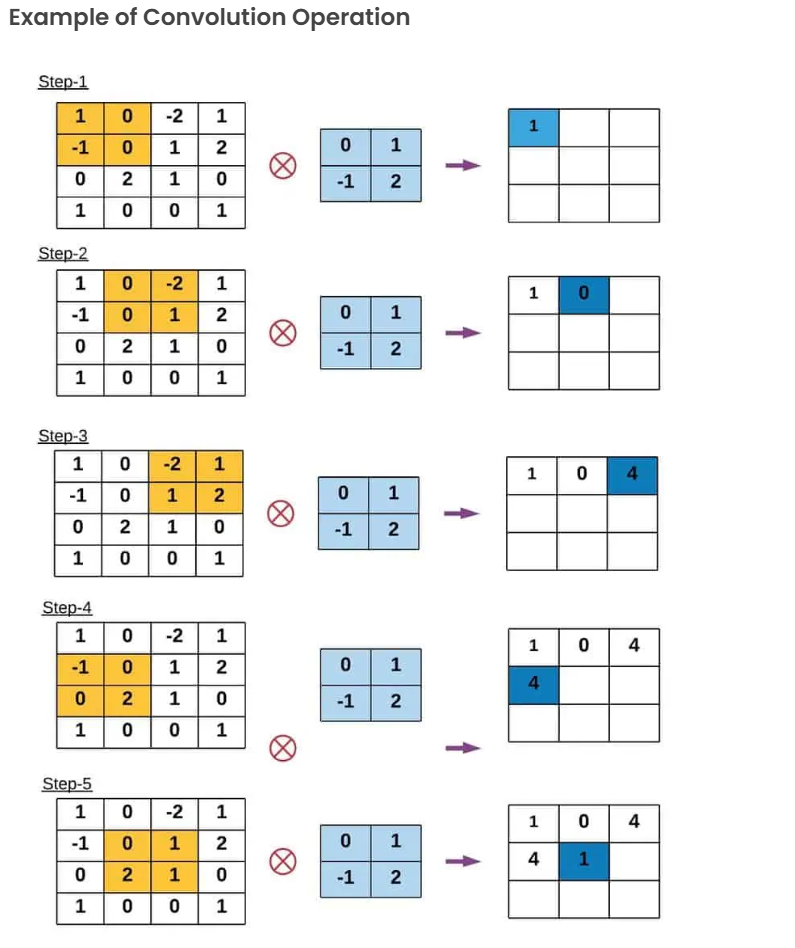

- At each step we are sliding a filter shaped window on image 
- Then doing element-wise multiplication
- Then summ all values 
- This will be value for corresponding block in output

- Shape of input image = $n \times n$   
Shape of filter = $f \times f$   
Shape of output = $(n-f+1) \times (n-f+1)$   

In deep learning, Filter is initialized with random values and then Backpropagation is used to get best values in filter (just like weights in ANNs)

This is one of main reasons why CNNs succeeded - because they do not have to rely on pre-built filters

Visit this website to get cool visualization on how convolution operation works:

[deeplizard.com](https://deeplizard.com/resource/pavq7noze2)

2. Multiple Channel, Single Filter

How convolutional operation works for image with multiple channels:
- This time a cuboid filter will slide through image
- Output will still be single layered

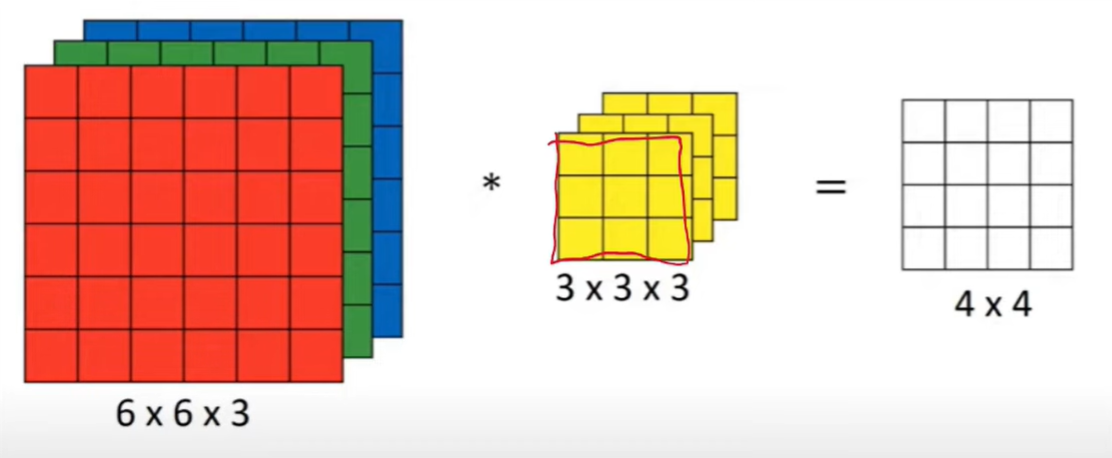

Iin this example:   
At each step $3 \times 3 \times 3 = 27$ element wise multiplication is done and then added together to give one value in feature map (output)

- Hence $(n\times n \times c) * (f \times f \times c) = ((n-f+1) \times (n-f+1)) $

3. Multiple Channel, Multiple Filters

How convolution operation works for multiple channel images with multiple filters
- Each filter will perform its operations individually 
- Then outputs can be merged into a single volume, which will be input for futher convolutional layers

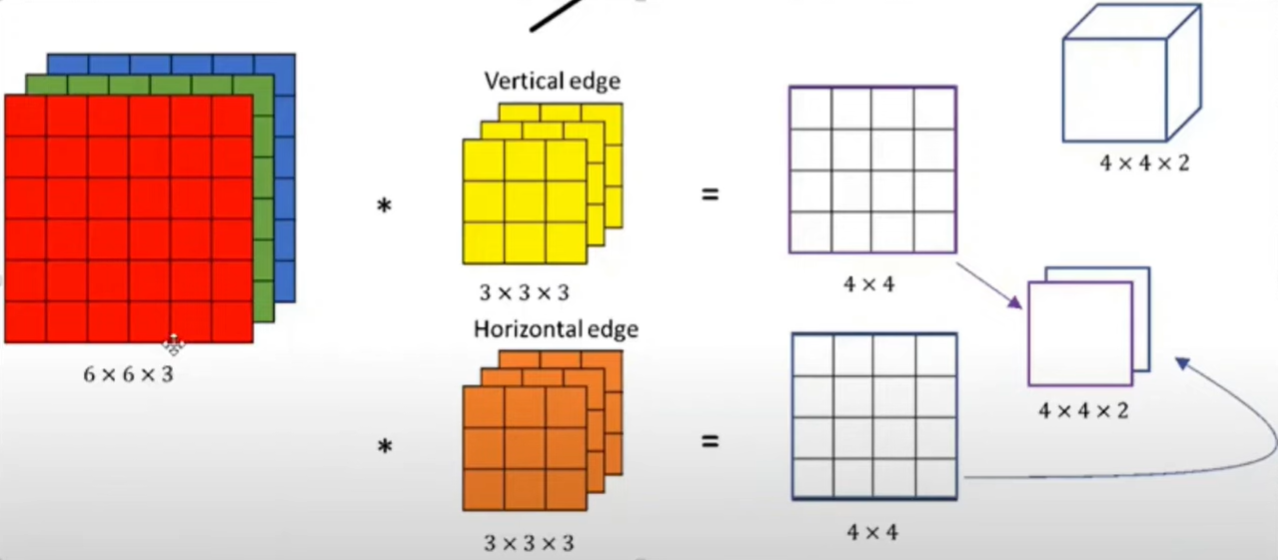

### Padding
Adding extra pixels (usually zero) around the borders of input image before applying convolution

Why?  
- Due to convolution, size of image decreases after each convolution operation. Padding prevents it
- In convolution, extreme top, bottom, right, left pixels take part in lesser number of operations. Hence in feature map, extreme pixels have less importance

Padding adds extra pixels around the borders of imput image before applying convolution 

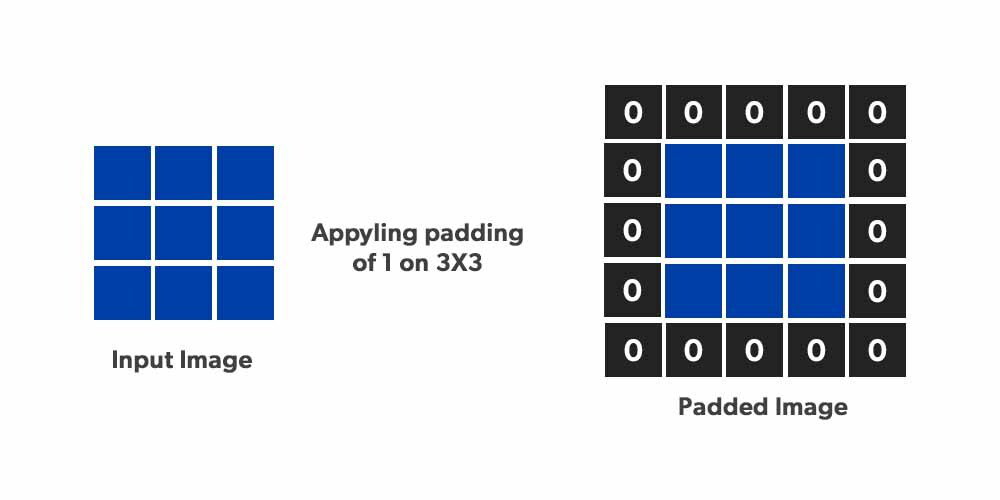

Now, shape of output will be given by: 
$$
(n + 2p - f + 1) \times (n + 2p - f + 1)
$$

- $p$ = number of padding

in the example below: n = 3, p = 1, f = 2:     
feature map has shape = 3 + 2(1) - 2 + 1 = $4 \times 4$

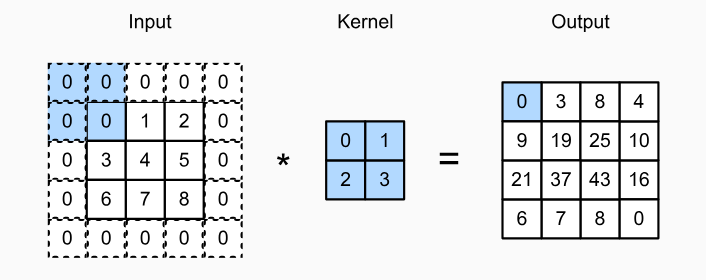

There are two ways to implement paddding in Keras:
| Type      | Padding added      | Output size                    | Use case                                |
| --------- | ------------------ | ------------------------------ | --------------------------------------- |
| **Valid** | No padding (P = 0) | Shrinks                        | When you want strict feature extraction |
| **Same**  | Padding added      | Same as input (for stride = 1) | When you want to preserve spatial size  |


In [1]:
from keras import Sequential 
from keras.layers import Dense, Conv2D, Flatten, Input
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [2]:
model = Sequential()

model.add(Input(shape = (28,28,1)))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='valid'))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='valid'))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='valid'))

model.add(Flatten())
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In summary, see the `Output Shape`, initial shape of input was 28x28, then in first output it became 26x26 then 24x24 and so on...  

In [3]:
model = Sequential()

model.add(Input(shape = (28,28,1)))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same'))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same'))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same'))

model.add(Flatten())
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

### Stride 
Stride is the amount of pixels by which kernel slides on the image.   
Typical stride is 1, which goes unmentioned. But it can be more   
If Stride > 1 it is called 'Strided Convolution'

Ex: stride = 2x2: fliter will slide with step of 2 horizontally then 2 vertically

<video controls src="20260405-1020-42.3518920.mp4" title="Title"></video>

Now the shape of feature map will be:    
- if img = ($n \times n$)  
- filter = ($f \times f$)
- padding = ($p$)
- stride = ($S \times S$)

$$
\text{Filter map} = (\frac{n + 2p - f}{S} + 1 \times \frac{n + 2p - f }{S} + 1)
$$

If output is in decimal, then we take floor function of output (largest int less than output)

- Increasing Stride also reduces the size of feature map 

In [4]:
model = Sequential()

model.add(Input(shape = (28,28,1)))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', strides=(2,2)))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', strides=(2,2)))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', strides=(2,2)))

model.add(Flatten())
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

Why Strides are used:
- Strides are basically step size of filter in every step in convolution operation
- They control
    - Resolution of features
    - Amount of computation 
    - How fast spatial size decreases